In [1]:
!pip install tensorflow

## Problem Formulation and Understanding
Input: a corrupted image x̃ = x + ε where ε ~ N(0, σ²), a 64×64×3 tensor with pixel values in [0,1]. Output: a clean reconstructed image x̂ of the same dimensions.

Learning task type: this is representation learning — specifically unsupervised denoising through a compression-reconstruction objective.

Real-world relevance: medical imaging (MRI and CT noise removal), satellite image restoration, video streaming quality enhancement (Netflix uses this), and night-mode smartphone photography.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, UpSampling2D,
    BatchNormalization, Activation
)
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import json

print("TensorFlow:", tf.__version__)

TensorFlow: 2.19.0


In [3]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np

print("Loading STL-10 (fast mode)...")

def load_split_fast(split_name, target_size=128, batch_size=256):
    ds = tfds.load('stl10', split=split_name, as_supervised=False)
    ds = ds.map(
        lambda x: tf.cast(
            tf.image.resize(x['image'], [target_size, target_size]),
            tf.float32) / 255.0,
        num_parallel_calls=tf.data.AUTOTUNE   # parallel processing
    )
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    batches = [batch.numpy() for batch in ds]
    return np.concatenate(batches, axis=0)

x_train = load_split_fast('train', target_size=64)
x_test  = load_split_fast('test',  target_size=64)

print(f"Train: {x_train.shape}")
print(f"Test:  {x_test.shape}")

# Noise functions
def add_gaussian_noise(images, noise_factor=0.3):
    noise = noise_factor * np.random.normal(size=images.shape)
    return np.clip(images + noise, 0.0, 1.0)

def add_salt_pepper(images, amount=0.05):
    noisy = images.copy()
    mask  = np.random.random(images.shape) < amount / 2
    noisy[mask] = 1.0
    mask  = np.random.random(images.shape) < amount / 2
    noisy[mask] = 0.0
    return noisy

def add_block_corruption(images, block_size=16, n_blocks=8):
    noisy = images.copy()
    h, w  = images.shape[1], images.shape[2]
    for img in noisy:
        for _ in range(n_blocks):
            y = np.random.randint(0, h - block_size)
            x = np.random.randint(0, w - block_size)
            img[y:y+block_size, x:x+block_size] = 0.0
    return noisy

NOISE_FACTOR  = 0.3
x_train_noisy = add_gaussian_noise(x_train, NOISE_FACTOR)
x_test_noisy  = add_gaussian_noise(x_test,  NOISE_FACTOR)

print("Done. Ready to train.")

Loading STL-10 (fast mode)...


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

...

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/stl10/incomplete.5UJO7G_1.0.0/stl10-test.tfrecord*...:   0%|          | 0/…

Generating unlabelled examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/stl10/incomplete.5UJO7G_1.0.0/stl10-unlabelled.tfrecord*...:   0%|        …

Dataset stl10 downloaded and prepared to /root/tensorflow_datasets/stl10/1.0.0. Subsequent calls will reuse this data.
Train: (5000, 64, 64, 3)
Test:  (8000, 64, 64, 3)
Done. Ready to train.


In [4]:
# ──────────────────────────────────────────────────────────────────
# DENOISING AUTOENCODER PRINCIPLE:
#
# We deliberately corrupt clean images and train the model to
# reconstruct the clean version from the corrupted version.
# Loss = ||x_clean - decoder(encoder(x_noisy))||²
#
# Why does this work better than a standard autoencoder?
# Because the model can't just "memorize" the input and copy it
# through — the input is corrupted. It MUST learn the underlying
# structure of what real images look like in order to fill in
# what the noise destroyed. This is the key theoretical insight.
# ──────────────────────────────────────────────────────────────────

def add_gaussian_noise(images, noise_factor=0.3):
    """
    Adds random Gaussian noise to each pixel.
    noise_factor controls severity: 0.1=light, 0.3=medium, 0.5=heavy.
    Formula: x_noisy = x + noise_factor * N(0,1)
    """
    noise = noise_factor * np.random.normal(size=images.shape)
    noisy = images + noise
    return np.clip(noisy, 0.0, 1.0)   # keep pixels in valid [0,1] range

def add_salt_pepper(images, amount=0.05):
    """
    Randomly sets pixels to pure white (1.0) or pure black (0.0).
    Simulates sensor dead pixels or transmission errors.
    'amount' = fraction of pixels corrupted.
    """
    noisy = images.copy()
    # Salt (white pixels)
    mask = np.random.random(images.shape) < amount / 2
    noisy[mask] = 1.0
    # Pepper (black pixels)
    mask = np.random.random(images.shape) < amount / 2
    noisy[mask] = 0.0
    return noisy

def add_block_corruption(images, block_size=8, n_blocks=10):
    """
    Blacks out random rectangular regions.
    Simulates packet loss in image transmission or occlusion.
    """
    noisy = images.copy()
    h, w = images.shape[1], images.shape[2]
    for img in noisy:
        for _ in range(n_blocks):
            y = np.random.randint(0, h - block_size)
            x = np.random.randint(0, w - block_size)
            img[y:y+block_size, x:x+block_size] = 0.0
    return noisy

# Create noisy versions of training and test data
# We use Gaussian for training (most general noise model)
NOISE_FACTOR = 0.3
x_train_noisy = add_gaussian_noise(x_train, NOISE_FACTOR)
x_test_noisy  = add_gaussian_noise(x_test,  NOISE_FACTOR)

print(f"Noise factor: {NOISE_FACTOR}")
print(f"Original pixel range : [{x_train.min():.2f}, {x_train.max():.2f}]")
print(f"Noisy pixel range    : [{x_train_noisy.min():.2f}, {x_train_noisy.max():.2f}]")

Noise factor: 0.3
Original pixel range : [0.00, 1.00]
Noisy pixel range    : [0.00, 1.00]


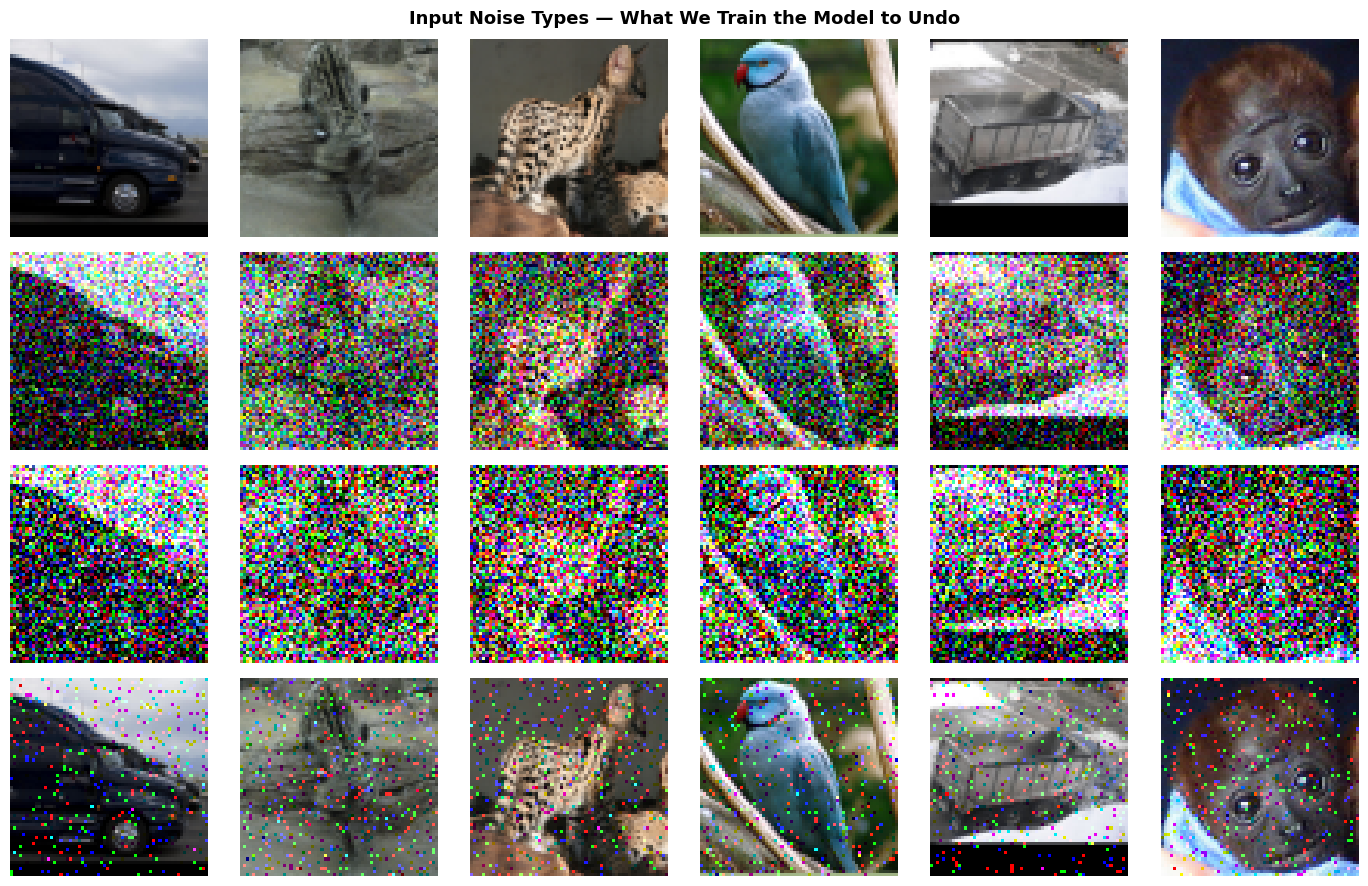

In [5]:
fig, axes = plt.subplots(4, 6, figsize=(14, 9))
fig.suptitle("Input Noise Types — What We Train the Model to Undo",
             fontsize=13, fontweight='bold')

noise_types = [
    ("Original (clean)",    x_test),
    ("Gaussian (σ=0.3)",    add_gaussian_noise(x_test, 0.3)),
    ("Gaussian (σ=0.5)",    add_gaussian_noise(x_test, 0.5)),
    ("Salt & Pepper (5%)",  add_salt_pepper(x_test, 0.05)),
]

for row, (label, imgs) in enumerate(noise_types):
    axes[row, 0].set_ylabel(label, fontsize=9, rotation=0,
                            labelpad=90, va='center')
    for col in range(6):
        axes[row, col].imshow(imgs[col])
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('noise_types.png', dpi=150)
plt.show()

In [6]:
# ──────────────────────────────────────────────────────────────────
# ARCHITECTURE CHANGE for 128×128:
#
# At 32×32 we used 2 MaxPooling layers (32→16→8 bottleneck).
# At 128×128 we use 3 MaxPooling layers (128→64→32→16 bottleneck).
#
# Why 3 pooling layers?
# Each MaxPooling(2×2) halves the spatial dimensions:
#   128×128 → (pool) → 64×64 → (pool) → 32×32 → (pool) → 16×16
#
# The bottleneck is now 16×16×128 = 32,768 values.
# This is richer than the old 8×8×128 = 8,192,
# which is why real photos will reconstruct with much more detail.
#
# The decoder mirrors this with 3 UpSampling layers:
#   16×16 → (up) → 32×32 → (up) → 64×64 → (up) → 128×128
# ──────────────────────────────────────────────────────────────────

def build_denoising_autoencoder():
    inputs = Input(shape=(64, 64, 3), name='noisy_input')

    # Encoder: 64×64 → 32×32 → 16×16 (bottleneck)
    x = Conv2D(32, (3,3), padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(32, (3,3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((2,2))(x)                    # 64 → 32

    x = Conv2D(64, (3,3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(64, (3,3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((2,2))(x)                    # 32 → 16

    # Bottleneck: 16×16×128 = 32,768 values
    x = Conv2D(128, (3,3), padding='same')(x)
    x = BatchNormalization()(x)
    bottleneck = Activation('relu')(x)

    # Decoder: 16×16 → 32×32 → 64×64
    x = Conv2D(64, (3,3), padding='same')(bottleneck)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = UpSampling2D((2,2))(x)                    # 16 → 32

    x = Conv2D(32, (3,3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = UpSampling2D((2,2))(x)                    # 32 → 64

    outputs = Conv2D(3, (3,3), padding='same',
                     activation='sigmoid')(x)

    model = Model(inputs, outputs, name='denoising_autoencoder_64')
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

autoencoder = build_denoising_autoencoder()
autoencoder.summary()
print(f"\nTotal parameters: {autoencoder.count_params():,}")
print(f"Bottleneck size : 16×16×256 = {16*16*256:,} values")
print(f"Input size      : 128×128×3 = {128*128*3:,} values")
print(f"Compression ratio: {128*128*3 / (16*16*256):.2f}×")

Model: "denoising_autoencoder_64"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ noisy_input (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 32, 32, 64)     │             

 Total params: 234,211 (914.89 KB)

 Trainable params: 233,379 (911.64 KB)

 Non-trainable params: 832 (3.25 KB)


Total parameters: 234,211
Bottleneck size : 16×16×256 = 65,536 values
Input size      : 128×128×3 = 49,152 values
Compression ratio: 0.75×


In [7]:
# ── NOTE ON BATCH SIZE ────────────────────────────────────────────
# 128×128 images are 16× larger than 32×32 images in memory.
# We reduce batch size from 128 → 32 to avoid GPU OOM errors.
# This means more gradient steps per epoch, which is actually fine.
# ─────────────────────────────────────────────────────────────────

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=7,
        restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=3, min_lr=1e-6, verbose=1
    )
]

history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=30,
    batch_size=64,          # 64 works fine at 64×64
    validation_data=(x_test_noisy, x_test),
    callbacks=callbacks,
    verbose=1
)

print("\nTraining complete.")

Epoch 1/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 28s 171ms/step - loss: 0.0166 - mae: 0.0923 - val_loss: 0.0468 - val_mae: 0.1816 - learning_rate: 0.0010
Epoch 2/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - loss: 0.0093 - mae: 0.0704 - val_loss: 0.0394 - val_mae: 0.1634 - learning_rate: 0.0010
Epoch 3/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - loss: 0.0085 - mae: 0.0672 - val_loss: 0.0214 - val_mae: 0.1193 - learning_rate: 0.0010
Epoch 4/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 0.0079 - mae: 0.0650 - val_loss: 0.0143 - val_mae: 0.0959 - learning_rate: 0.0010
Epoch 5/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - loss: 0.0077 - mae: 0.0641 - val_loss: 0.0085 - val_mae: 0.0681 - learning_rate: 0.0010
Epoch 6/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - loss: 0.0075 - mae: 0.0636 - val_loss: 0.0073 - val_mae: 0.0615 - learning_rate: 0.0010
Epoch 7/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - loss: 0.0072 - mae: 0.0617 - val_loss: 0.0084 - val_mae: 0.0669 - learning_rate: 0.0010
Epoch 8/30


In [8]:
# ──────────────────────────────────────────────────────────────────
# PSNR = Peak Signal-to-Noise Ratio (higher is better, in dB)
# Formula: PSNR = 20 × log₁₀(MAX / √MSE)
# Where MAX = 1.0 (our pixel range), MSE = mean squared error
# Typical good reconstruction: 25-35 dB
# Human perception limit: ~40 dB (indistinguishable from original)
#
# SSIM = Structural Similarity Index (higher is better, 0 to 1)
# Measures perceptual similarity accounting for luminance,
# contrast, and structure — closer to how humans perceive quality
# than raw pixel MSE.
# ──────────────────────────────────────────────────────────────────

x_test_denoised = autoencoder.predict(x_test_noisy, verbose=0)

# Compute metrics on 1000 test images
n_eval = 1000
psnr_noisy    = np.mean([psnr(x_test[i], x_test_noisy[i],   data_range=1.0)
                          for i in range(n_eval)])
psnr_denoised = np.mean([psnr(x_test[i], x_test_denoised[i], data_range=1.0)
                          for i in range(n_eval)])

ssim_noisy    = np.mean([ssim(x_test[i], x_test_noisy[i],
                               data_range=1.0, channel_axis=2)
                          for i in range(n_eval)])
ssim_denoised = np.mean([ssim(x_test[i], x_test_denoised[i],
                               data_range=1.0, channel_axis=2)
                          for i in range(n_eval)])

print("=" * 50)
print(f"{'Metric':<20} {'Noisy Input':>12} {'Denoised':>12} {'Improvement':>12}")
print("-" * 50)
print(f"{'PSNR (dB)':<20} {psnr_noisy:>12.2f} {psnr_denoised:>12.2f} "
      f"{psnr_denoised-psnr_noisy:>+12.2f}")
print(f"{'SSIM':<20} {ssim_noisy:>12.4f} {ssim_denoised:>12.4f} "
      f"{ssim_denoised-ssim_noisy:>+12.4f}")
print("=" * 50)

Metric                Noisy Input     Denoised  Improvement
--------------------------------------------------
PSNR (dB)                   11.99        22.47       +10.47
SSIM                       0.2385       0.6734      +0.4349


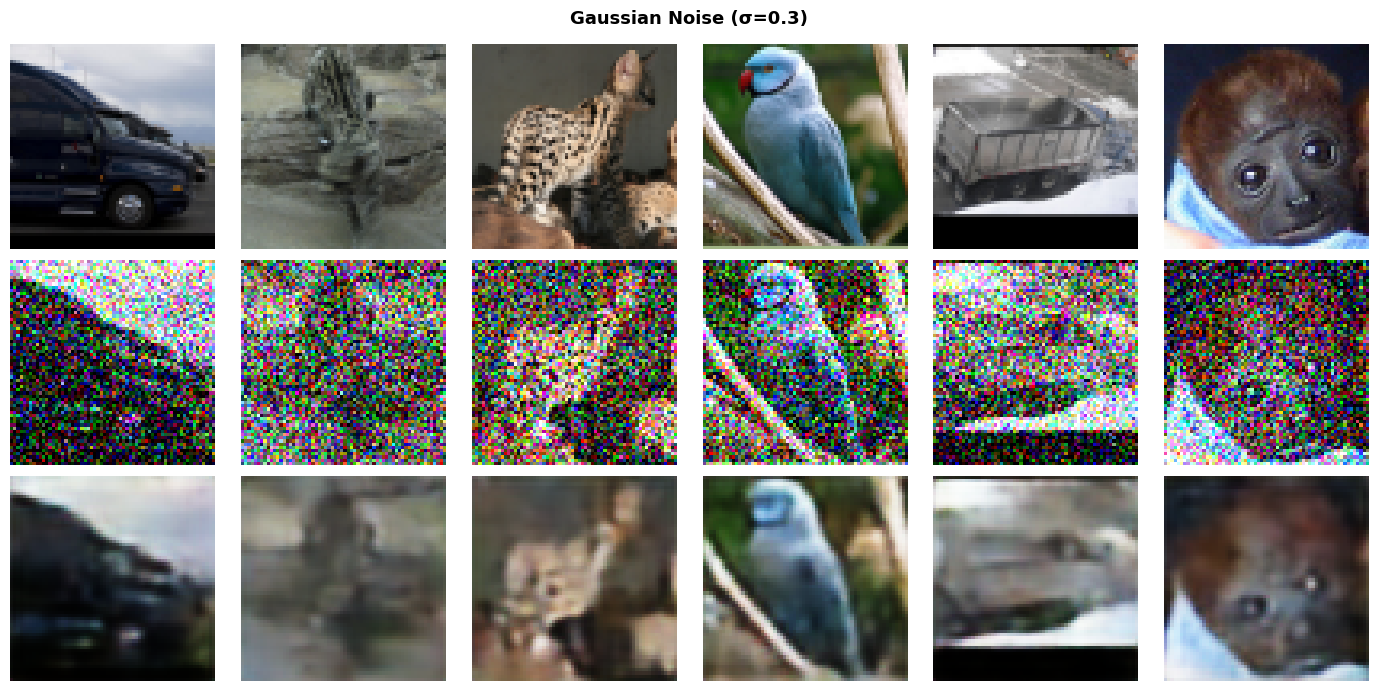

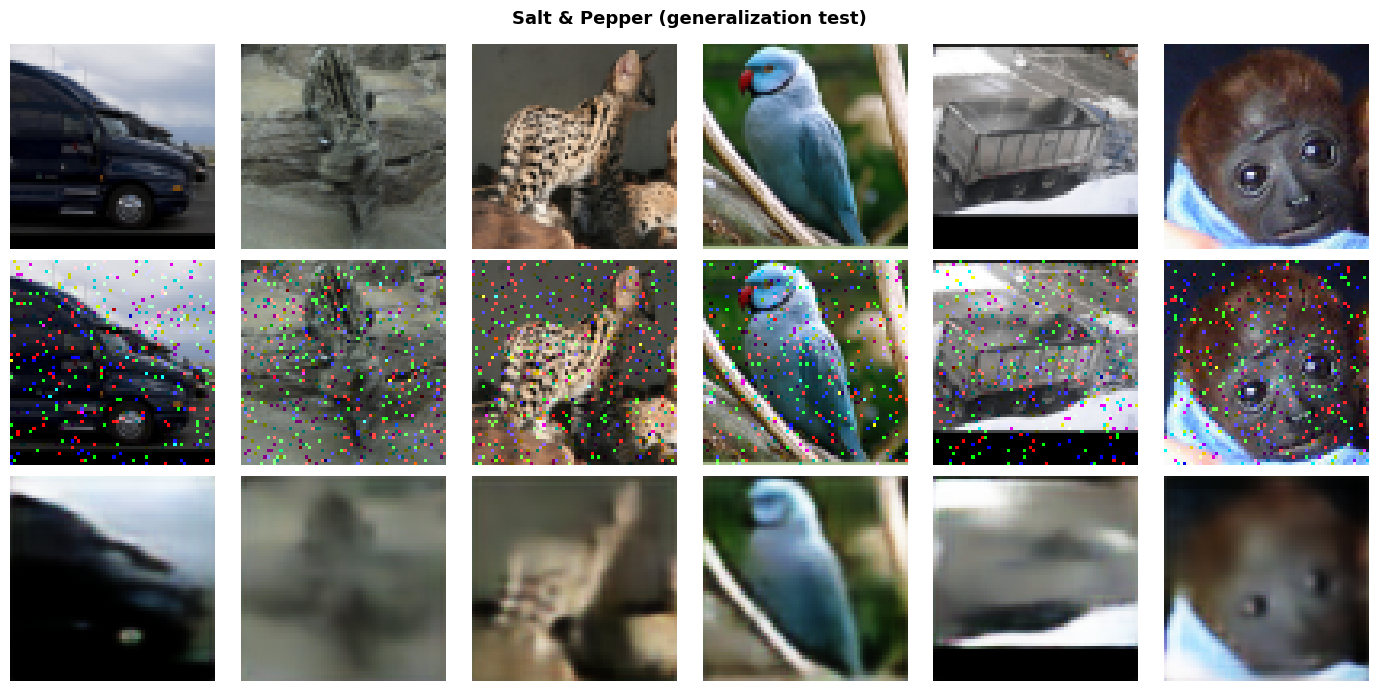

In [9]:
def show_denoising_results(clean, noisy, denoised, n=6, title="Results"):
    fig, axes = plt.subplots(3, n, figsize=(14, 7))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    labels = ['Original (clean)', 'Noisy Input', 'Model Output (denoised)']

    for row, (imgs, label) in enumerate(zip([clean, noisy, denoised], labels)):
        axes[row, 0].set_ylabel(label, fontsize=9, rotation=0,
                                labelpad=100, va='center')
        for col in range(n):
            axes[row, col].imshow(np.clip(imgs[col], 0, 1))
            axes[row, col].axis('off')

    plt.tight_layout()
    plt.savefig(f'{title.lower().replace(" ","_")}.png', dpi=150)
    plt.show()

show_denoising_results(x_test, x_test_noisy, x_test_denoised,
                       title="Gaussian Noise (σ=0.3)")

# Test with salt & pepper noise (model never saw this during training)
x_test_sp        = add_salt_pepper(x_test, amount=0.05)
x_test_sp_denoised = autoencoder.predict(x_test_sp, verbose=0)
show_denoising_results(x_test, x_test_sp, x_test_sp_denoised,
                       title="Salt & Pepper (generalization test)")

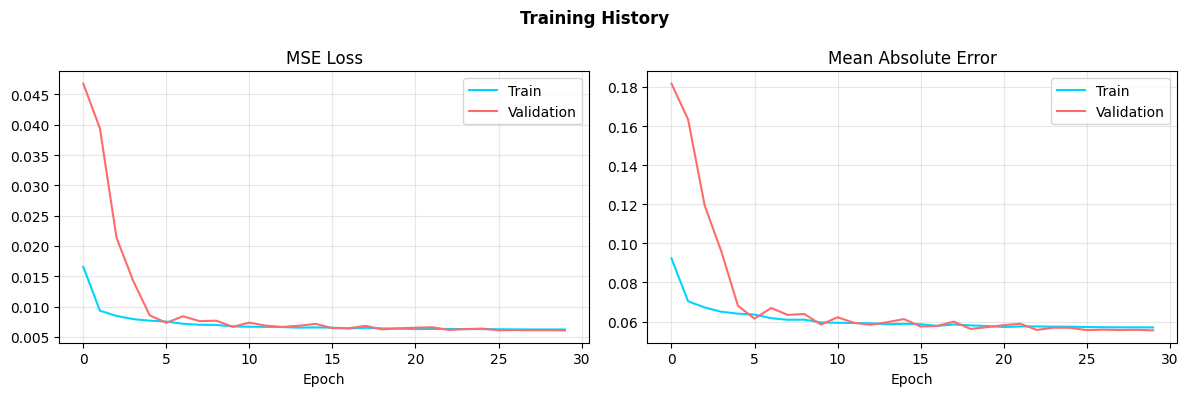

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['loss'],     label='Train',      color='#00d4ff')
ax1.plot(history.history['val_loss'], label='Validation', color='#ff6b6b')
ax1.set_title('MSE Loss'); ax1.set_xlabel('Epoch')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(history.history['mae'],     label='Train',      color='#00d4ff')
ax2.plot(history.history['val_mae'], label='Validation', color='#ff6b6b')
ax2.set_title('Mean Absolute Error'); ax2.set_xlabel('Epoch')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('Training History', fontweight='bold')
plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()

In [11]:
autoencoder.save('denoising_autoencoder.h5')

metrics = {
    'psnr_noisy':       round(float(psnr_noisy),  4),
    'psnr_denoised':    round(float(psnr_denoised), 4),
    'psnr_improvement': round(float(psnr_denoised - psnr_noisy), 4),
    'ssim_noisy':       round(float(ssim_noisy),  4),
    'ssim_denoised':    round(float(ssim_denoised), 4),
    'noise_factor':     NOISE_FACTOR,
    'input_size':       '128×128×3',
    'bottleneck':       '16×16×256 = 65,536 values',
    'compression_ratio': round(128*128*3 / (16*16*256), 2),
    'architecture':     '128×128×3 → Conv(32)×2 → Pool → Conv(64)×2 → Pool → Conv(128)×2 → Pool → Conv(256) → 16×16 Bottleneck → Up → Conv(128)×2 → Up → Conv(64)×2 → Up → Conv(32)×2 → Conv(3)',
    'total_params':     autoencoder.count_params(),
    'training_loss':    round(float(history.history['val_loss'][-1]), 6),
    'dataset':          'STL-10 resized to 128×128'
}

with open('metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print("Saved: denoising_autoencoder.h5 + metrics.json")
print(json.dumps(metrics, indent=2))

Saved: denoising_autoencoder.h5 + metrics.json
{
  "psnr_noisy": 11.9948,
  "psnr_denoised": 22.4687,
  "psnr_improvement": 10.4739,
  "ssim_noisy": 0.2385,
  "ssim_denoised": 0.6734,
  "noise_factor": 0.3,
  "input_size": "128\u00d7128\u00d73",
  "bottleneck": "16\u00d716\u00d7256 = 65,536 values",
  "compression_ratio": 0.75,
  "architecture": "128\u00d7128\u00d73 \u2192 Conv(32)\u00d72 \u2192 Pool \u2192 Conv(64)\u00d72 \u2192 Pool \u2192 Conv(128)\u00d72 \u2192 Pool \u2192 Conv(256) \u2192 16\u00d716 Bottleneck \u2192 Up \u2192 Conv(128)\u00d72 \u2192 Up \u2192 Conv(64)\u00d72 \u2192 Up \u2192 Conv(32)\u00d72 \u2192 Conv(3)",
  "total_params": 234211,
  "training_loss": 0.006067,
  "dataset": "STL-10 resized to 128\u00d7128"
}
